# Program 13: Feature Selection using Firefly Algorithm

This notebook implements a continuous-to-binary **Firefly Algorithm (FFA)** map for **Dimensionality Reduction (Feature Selection)**.
Our objective is to train a K-Nearest Neighbors classifier on a medical dataset, improving its predictive accuracy by filtering out irrelevant or noisy features using the attraction logic of fireflies.

In [6]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.linear_model import PassiveAggressiveClassifier
from sklearn.metrics import accuracy_score
from sklearn.preprocessing import StandardScaler
import warnings

warnings.filterwarnings('ignore')

### 1. Load Dataset and Establish a Baseline
We use the **Breast Cancer Wisconsin** dataset, which has 30 continuous features. A KNN model is trained using all 30 features to establish our baseline.

In [7]:
data = load_breast_cancer()
X = data.data
y = data.target

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# Scaling is crucial for ML models
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Baseline Accuracy with ALL features using a Passive Aggressive Classifier
model_base = PassiveAggressiveClassifier(max_iter=1000, random_state=42)
model_base.fit(X_train_scaled, y_train)
base_preds = model_base.predict(X_test_scaled)
base_acc = accuracy_score(y_test, base_preds)

print(f"Original number of features: {X.shape[1]}")
print(f"Baseline PA Classifier Accuracy (All Features): {base_acc:.4f}")

Original number of features: 30
Baseline PA Classifier Accuracy (All Features): 0.9766


### 2. Define Firefly Algorithm Mechanics
The Firefly moves in a continuous space. We map its coordinates to Binary (0 or 1) using a `sigmoid` activation function to determine whether a subset feature is selected.

In [8]:
def sigmoid(x):
    return 1 / (1 + np.exp(-np.clip(x, -10, 10)))

def evaluate_fitness(position, X_train, X_test, y_train, y_test):
    # Convert continuous position to binary selection mask (0 = drop, 1 = keep)
    binary_position = sigmoid(position) >= 0.5
    
    # Penalty if no features are selected
    if np.sum(binary_position) == 0:
        return 0.0
        
    X_train_sel = X_train[:, binary_position]
    X_test_sel = X_test[:, binary_position]
    
    # Train and evaluate using the rare Passive Aggressive Classifier
    model = PassiveAggressiveClassifier(max_iter=1000, random_state=42)
    model.fit(X_train_sel, y_train)
    acc = accuracy_score(y_test, model.predict(X_test_sel))
    
    return acc

### 3. Run the Firefly Feature Selection Loop

In [9]:
np.random.seed(42)

# FFA Parameters
num_fireflies = 15
num_features = X.shape[1]
max_iter = 30
alpha = 0.2      # Randomization factor
beta0 = 1.0      # Base attractiveness at r=0
gamma = 1.0      # Light absorption coefficient

# 1. Initialize random continuous positions
positions = np.random.randn(num_fireflies, num_features)
fitness = np.zeros(num_fireflies)

best_global_fitness = 0.0
best_global_position = None
history = []

print("Starting Firefly Optimization...")
for t in range(max_iter):
    # Evaluate Brightness (Fitness)
    for i in range(num_fireflies):
        fitness[i] = evaluate_fitness(positions[i], X_train_scaled, X_test_scaled, y_train, y_test)
        
        if fitness[i] > best_global_fitness:
            best_global_fitness = fitness[i]
            best_global_position = positions[i].copy()
            
    # Attract Fireflies to brighter ones
    for i in range(num_fireflies):
        for j in range(num_fireflies):
            if fitness[j] > fitness[i]: # j is brighter
                # Calculate Euclidean distance
                r = np.linalg.norm(positions[i] - positions[j])
                # Attractiveness decreases as distance increases
                beta = beta0 * np.exp(-gamma * (r**2))
                
                rand_step = alpha * (np.random.rand(num_features) - 0.5)
                
                # Move firefly i towards brighter j
                positions[i] += beta * (positions[j] - positions[i]) + rand_step
    
    history.append(best_global_fitness)
    if (t+1) % 5 == 0 or t == 0:
        print(f"Generation {t+1}/{max_iter} : Current Best Accuracy = {best_global_fitness:.4f}")

Starting Firefly Optimization...
Generation 1/30 : Current Best Accuracy = 0.9825
Generation 5/30 : Current Best Accuracy = 0.9825
Generation 10/30 : Current Best Accuracy = 0.9825
Generation 15/30 : Current Best Accuracy = 0.9825
Generation 20/30 : Current Best Accuracy = 0.9883
Generation 25/30 : Current Best Accuracy = 0.9883
Generation 30/30 : Current Best Accuracy = 0.9883


### 4. Evaluation of the Reduced Feature Set


=== FIREFLY OPTIMIZATION RESULTS ===
Baseline Accuracy : 0.9766 (using 30 features)
Optimized Accuracy: 0.9883 (using 15 features)
Improvement       : +1.17%

=== SELECTED FEATURES ===
01. mean radius
02. mean texture
03. mean smoothness
04. mean concavity
05. area error
06. smoothness error
07. compactness error
08. concavity error
09. concave points error
10. symmetry error
11. worst texture
12. worst area
13. worst smoothness
14. worst symmetry
15. worst fractal dimension


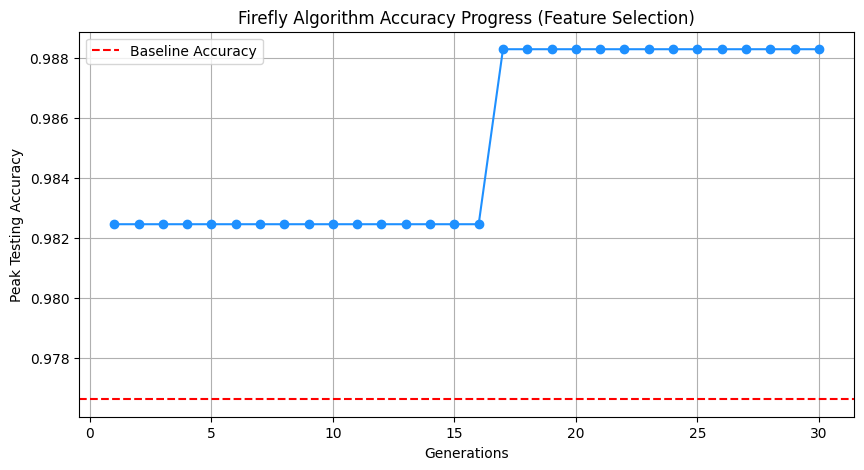

In [10]:
# Decoding the best firefly into binary bits
best_binary_features = sigmoid(best_global_position) >= 0.5
selected_indices = np.where(best_binary_features)[0]
selected_feature_names = data.feature_names[selected_indices]

print("\n=== FIREFLY OPTIMIZATION RESULTS ===")
print(f"Baseline Accuracy : {base_acc:.4f} (using {num_features} features)")
print(f"Optimized Accuracy: {best_global_fitness:.4f} (using {len(selected_indices)} features)")
print(f"Improvement       : +{(best_global_fitness - base_acc)*100:.2f}%")

print("\n=== SELECTED FEATURES ===")
for i, feat in enumerate(selected_feature_names, 1):
    print(f"{i:02d}. {feat}")

plt.figure(figsize=(10, 5))
plt.plot(range(1, max_iter + 1), history, marker='o', linestyle='-', color='dodgerblue')
plt.axhline(y=base_acc, color='r', linestyle='--', label='Baseline Accuracy')
plt.title('Firefly Algorithm Accuracy Progress (Feature Selection)')
plt.xlabel('Generations')
plt.ylabel('Peak Testing Accuracy')
plt.legend()
plt.grid(True)
plt.show()